# SIGMA - Decision Tree Training (Enhanced)

Notebook ini digunakan untuk:
1. Memuat dataset SIGMA.
2. Melakukan eksplorasi data.
3. Melatih model Decision Tree.
4. Mengevaluasi performa model.
5. Menampilkan Feature Importance.
6. Menyimpan model untuk integrasi backend SIGMA.

Notebook ini mengikuti masukan advisor:

- Data Understanding
- Missing Value Check
- Duplicate Check
- Correlation Matrix
- Train/Test Split
- Cross Validation
- Overfitting Check
- Accuracy, Precision, Recall, F1 Score
- Recall Kelas Berisiko
- Feature Importance
- Visualisasi Pohon Keputusan
- Simpan Model


## Import Library

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


## Load Dataset

In [2]:

BASE_DIR = Path.cwd().parent

DATASET_PATH = BASE_DIR / "dataset" / "SIGMA_dataset_300.csv"

df = pd.read_csv(DATASET_PATH)

df.head()


,id,progres_skripsi,frekuensi_bimbingan_bulanan,keterlambatan_milestone_hari,streak_aktivitas_mingguan,jumlah_revisi_aktif,risiko_keterlambatan
0,1,20,2,44,4,8,Berisiko
1,2,18,1,50,4,7,Berisiko
2,3,58,3,60,4,6,Berisiko
3,4,35,0,51,0,3,Berisiko
4,5,41,0,40,0,8,Berisiko


## Informasi Dataset

In [3]:

print("Shape:", df.shape)

df.info()

df.describe()


Shape: (300, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   id                            300 non-null    int64 
 1   progres_skripsi               300 non-null    int64 
 2   frekuensi_bimbingan_bulanan   300 non-null    int64 
 3   keterlambatan_milestone_hari  300 non-null    int64 
 4   streak_aktivitas_mingguan     300 non-null    int64 
 5   jumlah_revisi_aktif           300 non-null    int64 
 6   risiko_keterlambatan          300 non-null    object
dtypes: int64(6), object(1)
memory usage: 16.5+ KB


,id,progres_skripsi,frekuensi_bimbingan_bulanan,keterlambatan_milestone_hari,streak_aktivitas_mingguan,jumlah_revisi_aktif
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,54.886667,2.270000,21.896667,3.556667,4.010000
std,86.746758,23.826164,1.401301,17.604898,2.065837,2.437836
min,1.000000,6.000000,0.000000,0.000000,0.000000,0.000000
25%,75.750000,34.750000,1.000000,6.000000,2.000000,2.000000
50%,150.500000,53.500000,2.000000,16.000000,4.000000,4.000000
75%,225.250000,77.000000,3.000000,37.000000,5.000000,6.000000
max,300.000000,99.000000,5.000000,60.000000,7.000000,8.000000


## Missing Value Check

In [4]:

df.isnull().sum()


id                              0
progres_skripsi                 0
frekuensi_bimbingan_bulanan     0
keterlambatan_milestone_hari    0
streak_aktivitas_mingguan       0
jumlah_revisi_aktif             0
risiko_keterlambatan            0
dtype: int64

## Duplicate Check

In [5]:

print("Jumlah Duplicate:")
print(df.duplicated().sum())


Jumlah Duplicate:
0


## Distribusi Label

In [6]:

df["risiko_keterlambatan"].value_counts()


risiko_keterlambatan
Berisiko      145
Cukup Aman     91
On Track       64
Name: count, dtype: int64

## Correlation Matrix

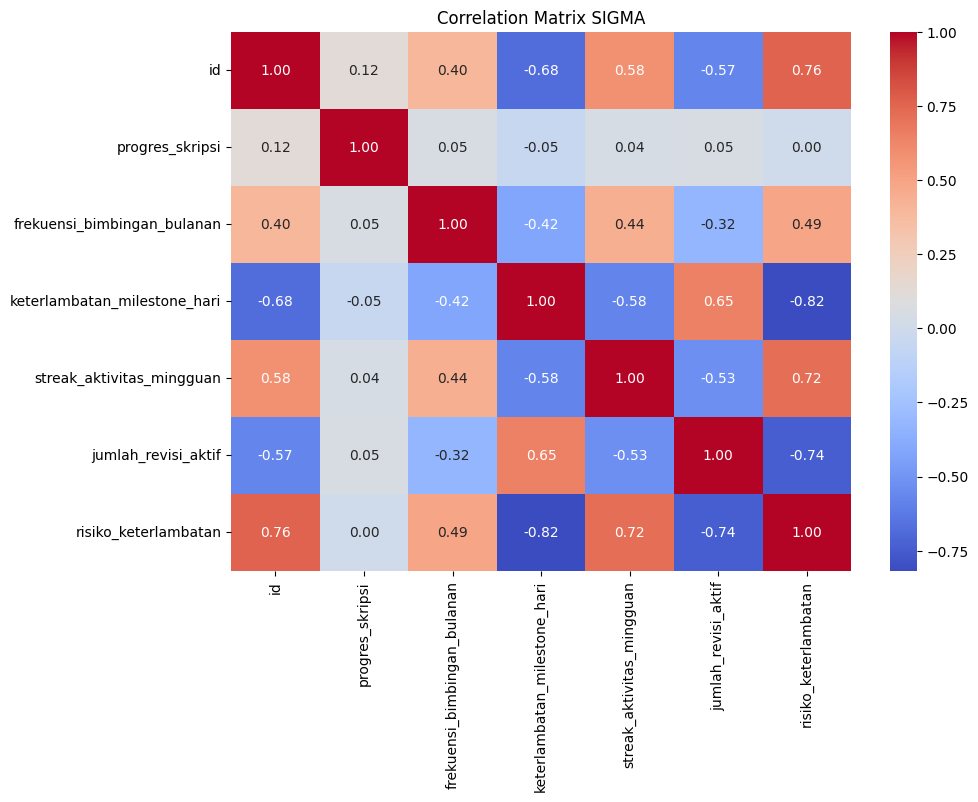

In [7]:

corr_df = df.copy()

temp_encoder = LabelEncoder()

corr_df["risiko_keterlambatan"] = temp_encoder.fit_transform(
    corr_df["risiko_keterlambatan"]
)

plt.figure(figsize=(10,7))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix SIGMA")

plt.show()


## Feature dan Target

In [8]:

X = df.drop(
    columns=[
        "id",
        "risiko_keterlambatan"
    ]
)

y = df["risiko_keterlambatan"]


## Label Encoding

In [9]:

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)


['Berisiko' 'Cukup Aman' 'On Track']


## Train Test Split

In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (240, 5)
Test : (60, 5)


## Training Decision Tree

In [11]:

dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

dt_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=42)

## Cross Validation

In [12]:

cv_scores = cross_val_score(
    dt_model,
    X,
    y_encoded,
    cv=5,
    scoring="f1_macro"
)

print("CV Scores:", cv_scores)
print("Mean F1 Macro:", cv_scores.mean())


CV Scores: [0.92217255 0.9053602  0.92698413 0.98482647 0.94814539]
Mean F1 Macro: 0.937497745439166


## Overfitting Check

In [13]:

train_pred = dt_model.predict(X_train)
test_pred = dt_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)


Train Accuracy: 0.9708333333333333
Test Accuracy : 0.8833333333333333


## Evaluasi Model

In [14]:

dt_pred = dt_model.predict(X_test)

accuracy = accuracy_score(y_test, dt_pred)

print("Accuracy:", accuracy)

print(
    classification_report(
        y_test,
        dt_pred,
        target_names=label_encoder.classes_
    )
)


Accuracy: 0.8833333333333333
              precision    recall  f1-score   support

    Berisiko       0.94      1.00      0.97        29
  Cukup Aman       0.76      0.89      0.82        18
    On Track       1.00      0.62      0.76        13

    accuracy                           0.88        60
   macro avg       0.90      0.83      0.85        60
weighted avg       0.90      0.88      0.88        60



## Recall Fokus Kelas Berisiko

In [15]:

report = classification_report(
    y_test,
    dt_pred,
    target_names=label_encoder.classes_,
    output_dict=True
)

print(
    "Recall Berisiko:",
    report["Berisiko"]["recall"]
)


Recall Berisiko: 1.0


## Confusion Matrix

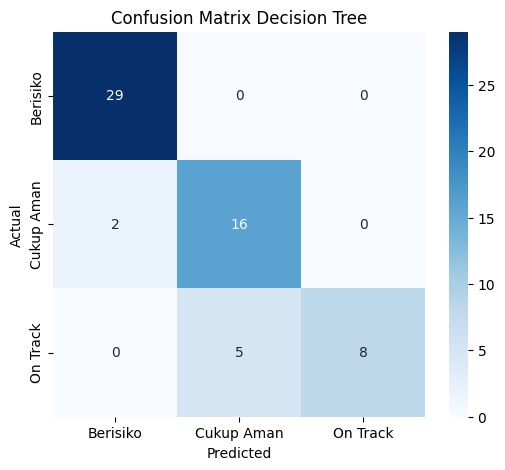

In [16]:

cm = confusion_matrix(
    y_test,
    dt_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix Decision Tree")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


## Feature Importance

In [17]:

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance


,Feature,Importance
2,keterlambatan_milestone_hari,0.852686
3,streak_aktivitas_mingguan,0.087193
4,jumlah_revisi_aktif,0.057554
1,frekuensi_bimbingan_bulanan,0.002567
0,progres_skripsi,0.000000


## Visualisasi Feature Importance

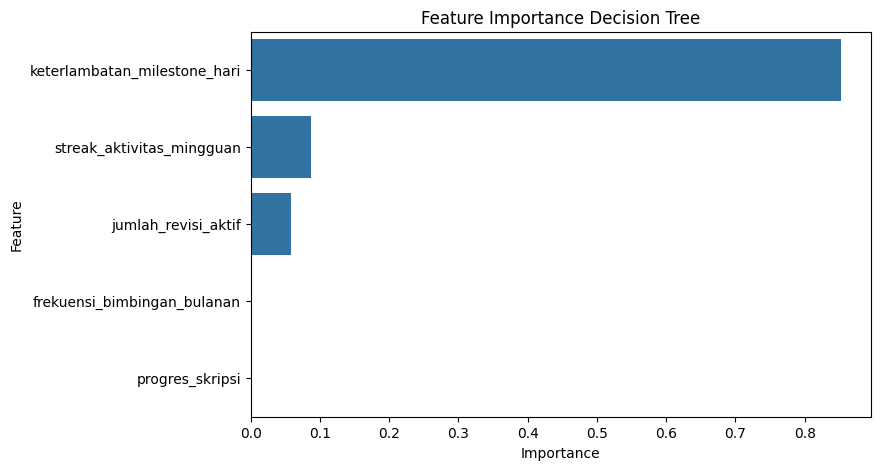

In [18]:

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance Decision Tree")

plt.show()


## Visualisasi Pohon Keputusan

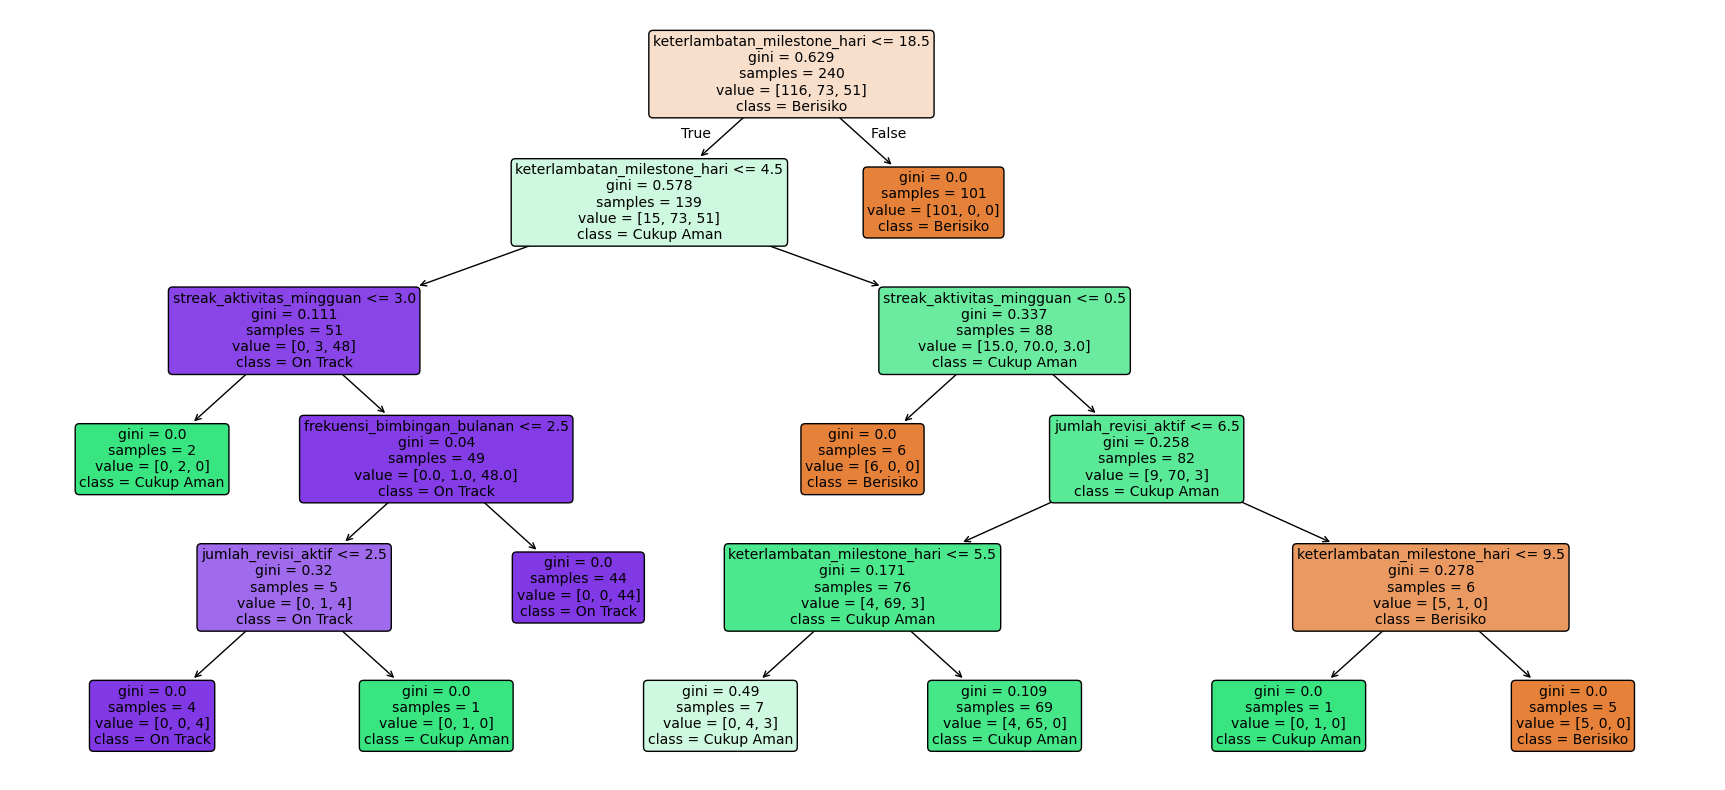

In [19]:

plt.figure(figsize=(22,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True
)

plt.show()


## Simpan Model

In [20]:

joblib.dump(
    dt_model,
    "sigma_decision_tree.pkl"
)

joblib.dump(
    label_encoder,
    "label_encoder.pkl"
)

print("Model berhasil disimpan")


Model berhasil disimpan


## Prediksi Data Baru

In [22]:

sample = pd.DataFrame([{
    "progres_skripsi":45,
    "frekuensi_bimbingan_bulanan":4,
    "keterlambatan_milestone_hari":14,
    "streak_aktivitas_mingguan":2,
    "jumlah_revisi_aktif":6
}])

pred = dt_model.predict(sample)

hasil = label_encoder.inverse_transform(pred)

print("Prediksi:", hasil[0])


Prediksi: Cukup Aman
